#NOTE

In [2]:
#analisi fatta in ambiente google drive
# con la versione anaconda ha funzionato

In [3]:
# SI FA UNA ANALISI DI REGRESSIONE LINEARE MULTIPLA

# LIBRERIE

In [1]:
#librerie di base
import pandas as pd
import numpy as np

In [2]:
#libreria per l'analisi dei dati
import statsmodels.api as sm
#from sklearn.linear_model import LinearRegression as lr

In [3]:
#libreria di supporto per l'analisi

# per lo scaling delle variabili numeriche
from sklearn.preprocessing import StandardScaler
# per eseguire il trainin e il test e la valutazione del modello
from sklearn.model_selection import train_test_split as envtest

In [4]:
#librerie di valutazione e misurazione del modello
from sklearn import metrics

In [5]:
#librerie grafiche
from matplotlib import pyplot as plt
import seaborn as sns
sns.set_theme()

In [6]:
# =============================================================
# =============================================================
#
# importo le funzioni personali creati per questa fase


#aggiunto quando ho spostato i file in una cartella a parte
import sys
sys.path.append("./Moduli")

import Moduli.Modulo_Fase_Analisi as pd_analisi

In [7]:
# =============================================================
# =============================================================
#
# importo le funzioni personali creati per questa fase


#aggiunto quando ho spostato i file in una cartella a parte
#import sys
#sys.path.append("./Moduli")

import Moduli.Modulo_Common as pd_common

#RECUPERO DATI

In [8]:
#caso google 
# df_incidenti = pd.read_csv( ".//Analisi//Incidenti_flat.csv")
# caso vscode
df_incidenti = pd.read_csv( pd_common.GetFolderAnalisi()+ "//Incidenti_flat.csv")

In [11]:
df_incidenti.head(4)

,Unnamed: 0,index,TIME_PERIOD,COD_RIP,DEN_RIP,COD_REG,DEN_REG,COD_UTS,DEN_UTS,PRO_COM,COMUNE,AREA_KMQ,POP_RES,POP_AL_KMQ,RESULT,RESULT_DESC,OBS_VALUE,TIPO_DATO,TIPO_DATO_DSC
0,0,0,2010,1,Nord-ovest,1,Piemonte,1,Torino,1001,Agliè,13.1462,2622,199.449271,F,Feriti,14,S,Storico
1,1,1,2011,1,Nord-ovest,1,Piemonte,1,Torino,1001,Agliè,13.1462,2615,198.916797,F,Feriti,6,S,Storico
2,2,2,2012,1,Nord-ovest,1,Piemonte,1,Torino,1001,Agliè,13.1462,2657,202.111637,F,Feriti,8,S,Storico
3,3,3,2013,1,Nord-ovest,1,Piemonte,1,Torino,1001,Agliè,13.1462,2722,207.056031,F,Feriti,5,S,Storico


In [12]:
df_incidenti.columns

Index(['Unnamed: 0', 'index', 'TIME_PERIOD', 'COD_RIP', 'DEN_RIP', 'COD_REG',
       'DEN_REG', 'COD_UTS', 'DEN_UTS', 'PRO_COM', 'COMUNE', 'AREA_KMQ',
       'POP_RES', 'POP_AL_KMQ', 'RESULT', 'RESULT_DESC', 'OBS_VALUE',
       'TIPO_DATO', 'TIPO_DATO_DSC'],
      dtype='object')

In [13]:
df_incidenti.TIME_PERIOD.unique()

array([2010, 2011, 2012, 2013, 2014, 2015, 2016, 2018, 2019, 2020, 2021,
       2022, 2023, 2024, 2017])

In [9]:
df_incidenti = df_incidenti.drop('Unnamed: 0', axis=1)

In [15]:
df_incidenti.columns

Index(['index', 'TIME_PERIOD', 'COD_RIP', 'DEN_RIP', 'COD_REG', 'DEN_REG',
       'COD_UTS', 'DEN_UTS', 'PRO_COM', 'COMUNE', 'AREA_KMQ', 'POP_RES',
       'POP_AL_KMQ', 'RESULT', 'RESULT_DESC', 'OBS_VALUE', 'TIPO_DATO',
       'TIPO_DATO_DSC'],
      dtype='object')

#PREPARAZIONE DATAFRAME DI ANALISI

##AMBITO DATI (CONTENUTO E TRASFORMAZIONI)

In [10]:
#feature : variabili indipendenti:  'TIME_PERIOD','PRO_COM','POP_AL_KMQ', 'RESULT'
#   NB le altre sono relazionate tra loro per cui le derivo semplicemente sapendo una di quelle considerate come feature
#   NB COME FATTO IN SCRIPT PRECEDENTE LE VARIABILI IND. POP_RES E AREA_KMQ SONO STATE RIDOTTE A UNA SOLA POP_AL_KMQ CHE RACCOGLIE AMBEDUE LE INFORMAZIONI
#     RIDUCENDO GLI EFFETTI NEGATIVI DI INSERIRE PIù FEATURE E DOVE CORREGGERE IL RELATIVO EFFETTO - ES R QUADRO ADJUSTMENT
# variabile target: variabile dipendente: 'OBS_VALUE'
df_analisi = df_incidenti[['index','TIME_PERIOD','PRO_COM','POP_AL_KMQ', 'RESULT','OBS_VALUE']]

In [17]:
df_analisi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118111 entries, 0 to 118110
Data columns (total 6 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   index        118111 non-null  int64  
 1   TIME_PERIOD  118111 non-null  int64  
 2   PRO_COM      118111 non-null  int64  
 3   POP_AL_KMQ   118111 non-null  float64
 4   RESULT       118111 non-null  object 
 5   OBS_VALUE    118111 non-null  int64  
dtypes: float64(1), int64(4), object(1)
memory usage: 5.4+ MB


In [11]:
df_analisi['RESULT'] = df_analisi['RESULT'].astype('string')

C:\Users\pietr\AppData\Local\Temp\ipykernel_24364\2194147801.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_analisi['RESULT'] = df_analisi['RESULT'].astype('string')


In [15]:
df_analisi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118111 entries, 0 to 118110
Data columns (total 6 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   index        118111 non-null  int64  
 1   TIME_PERIOD  118111 non-null  int64  
 2   PRO_COM      118111 non-null  int64  
 3   POP_AL_KMQ   118111 non-null  float64
 4   RESULT       118111 non-null  string 
 5   OBS_VALUE    118111 non-null  int64  
dtypes: float64(1), int64(4), string(1)
memory usage: 5.4 MB


In [12]:
# LA COLONNA TESTUALE LA CONVERTO IN UNA FEATURE BOOLEAN
# SICCOME IL DOMINIO VALORI AMMESSO E' DI SOLO 2 VALORI CREO UNA SOLA COLONNA 0-1
# IN CUI DERIVO L'ALTRA QUANDO QUESTA E' 0 --> RIMUOVO LA DIPENDENZA TRA 2 COLONNE DATO CHE RIESCO A RICAVARE L'ALTRA
df_analisi['MORTI']=0

C:\Users\pietr\AppData\Local\Temp\ipykernel_24364\4177000675.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_analisi['MORTI']=0


In [13]:
df_analisi[df_analisi['RESULT']=='M'].head(3)

,index,TIME_PERIOD,PRO_COM,POP_AL_KMQ,RESULT,OBS_VALUE,MORTI
14,14,2023,1001,195.340134,M,1,0
30,30,2010,1002,240.544370,M,1,0
31,31,2011,1002,239.019524,M,1,0


In [14]:
maschera_filtro= df_analisi['RESULT']=='M'
nr_morti= df_analisi[maschera_filtro]['MORTI'].agg('size')
nr_morti

25325

In [15]:
nr_feriti= df_analisi[~maschera_filtro]['MORTI'].agg('size')
nr_feriti

92786

In [16]:
nr_tot= df_analisi['RESULT'].agg('size')
nr_tot

118111

In [17]:
nr_tot_ver = nr_feriti + nr_morti
print(nr_tot_ver)

118111


In [18]:
df_analisi.loc[maschera_filtro,'MORTI']=1

In [23]:
df_analisi.groupby('MORTI').agg('size')

MORTI
0    92786
1    25325
dtype: int64

In [24]:
#verifico eventuale correlazione tra le feature scelte :
# MATRICE DI CORRELAZIONE
df_analisi[['TIME_PERIOD','PRO_COM','POP_AL_KMQ', 'MORTI']].corr()

,TIME_PERIOD,PRO_COM,POP_AL_KMQ,MORTI
TIME_PERIOD,1.000000,0.010716,-0.000389,-0.026870
PRO_COM,0.010716,1.000000,0.008961,0.029060
POP_AL_KMQ,-0.000389,0.008961,1.000000,0.075612
MORTI,-0.026870,0.029060,0.075612,1.000000


In [29]:
#non esiste una forte correlazione tra le feature, la più alta è quello dei morti con la popolazione al kmq come ci si aspetterebbe
#ma il valore è tanto inferiore a 0.6 quindi non la ritengo correlata
# QUINDI NON SI EVIDENZIA SITUAZIONE DI MULTICOLLINEARITA'
0.078191 * 100

7.8191

In [25]:
# come analisi fatta precedentemente dopo il calcolo della densità
# essendo univoca posso tramite questa ricavare il comune a cui è associata
# quindi è come se esistesse una relazione tra le due per cui
# non considero pià neanche il comune ma solo la densita
df_analisi[['TIME_PERIOD','POP_AL_KMQ', 'MORTI']].corr()

,TIME_PERIOD,POP_AL_KMQ,MORTI
TIME_PERIOD,1.000000,-0.000389,-0.026870
POP_AL_KMQ,-0.000389,1.000000,0.075612
MORTI,-0.026870,0.075612,1.000000


##AMBITO ESPLORAZIONE VISIVA

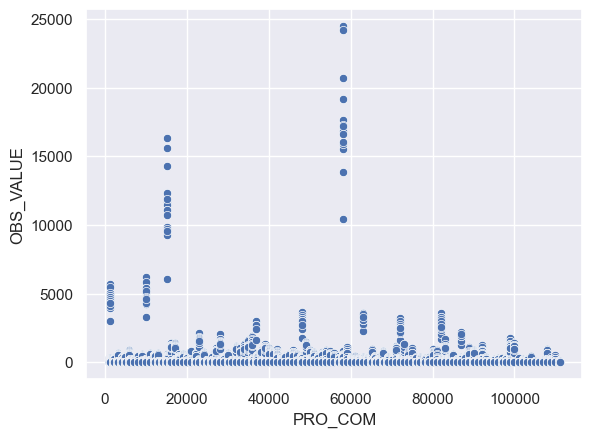

In [31]:
sns.scatterplot(x='PRO_COM', y='OBS_VALUE', data=df_analisi)
plt.show()

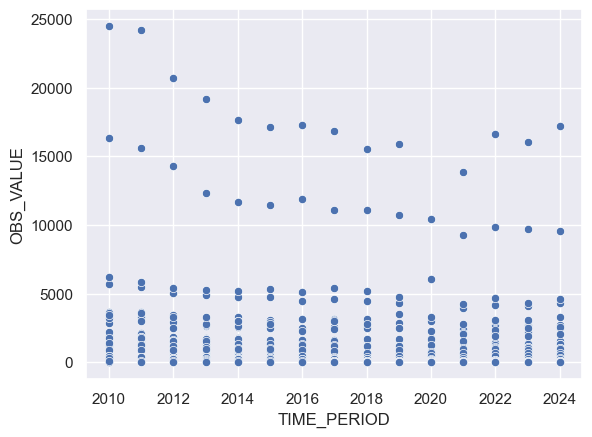

In [32]:
# da cambiare in lineare
sns.scatterplot(x='TIME_PERIOD', y='OBS_VALUE', data=df_analisi)
plt.show()

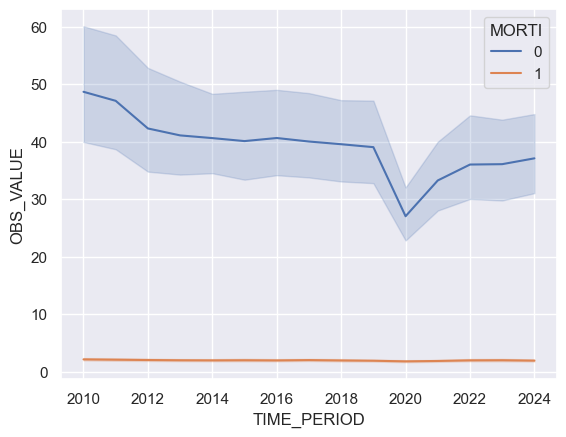

In [33]:
sns.lineplot(x='TIME_PERIOD', y='OBS_VALUE', hue='MORTI', data = df_analisi)
plt.show()

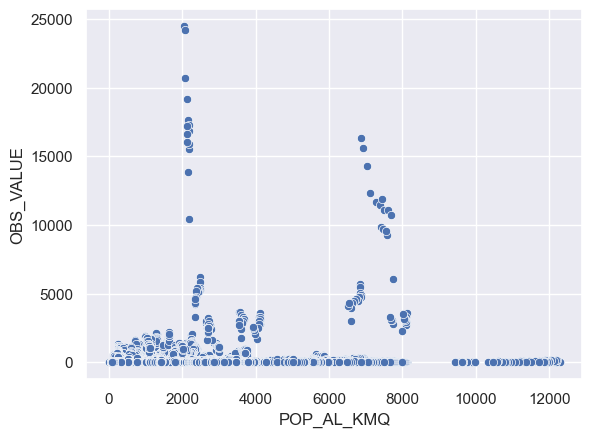

In [34]:
sns.scatterplot(x='POP_AL_KMQ', y='OBS_VALUE', data=df_analisi)
plt.show()

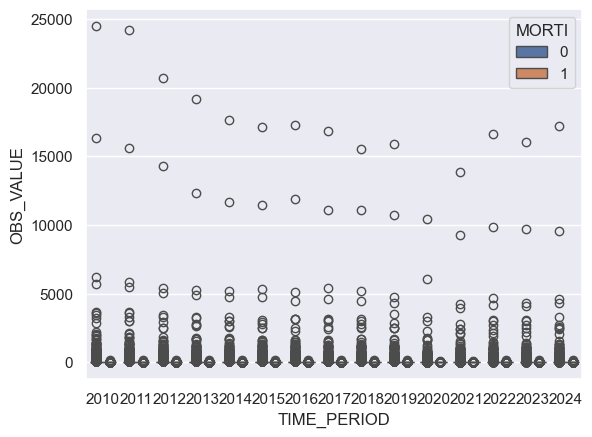

In [35]:

#sns.boxplot(x='TIME_PERIOD', y='OBS_VALUE', hue='MORTI', data = df_analisi)
#sns.boxplot(x='TIME_PERIOD', y='OBS_VALUE',  data = df_analisi)
sns.boxplot(x='TIME_PERIOD', y='OBS_VALUE', hue='MORTI', data = df_analisi)
plt.show()

In [36]:

#for feature in ['TIME_PERIOD','PRO_COM','POP_AL_KMQ']:
#    sns.boxplot(x=feature, y='MORTI', hue='OBS_VALUE', data = df_analisi)
#    plt.show()

#ANALISI CON MODELLO STATISTICO

dai grafici non ho una relazione lineare ma lo dimostro con i valori statistici restituiti dal modello

##PREPARAZIONE DATASET DI ANALISI, TRAINING E TEST

In [19]:
# definizione delle variabile dipendente - target
Y_Target = df_analisi['OBS_VALUE']

In [20]:
# definizione delle feature - variabili indipendenti
# nb come detto prima rimuovo 'PRO_COM',
X_Feature = df_analisi[['TIME_PERIOD','POP_AL_KMQ', 'MORTI']]

In [21]:
# aggiungo la costante
X_Feature = sm.add_constant(data=X_Feature)

In [22]:
# DEFINISCO GLI AMBIENTI DI TEST E TRAINING
X_train, X_test, Y_train, Y_test = envtest(X_Feature, Y_Target, test_size=0.3,random_state=2020)

In [23]:
#eseguo lo scaling ambiente Training
std_scaler = StandardScaler()
X_train_scaling = std_scaler.fit_transform(X_train)

In [24]:
#eseguo lo scaling ambiente test
std_scaler = StandardScaler()
X_test_scaling = std_scaler.fit_transform(X_test)

In [25]:
# definizione del modello statistico MULTI LINEAR REGRESSION
model_mlr= sm.OLS(Y_train ,X_train_scaling)

##ALLENAMENTO MODELLO

In [26]:
#allenamento del modello
MLR_Risultato=model_mlr.fit()

## VALUTAZIONE MODELLO

In [34]:
#lettura statistiche E LETTURA DEI PARAMETRI INTERNI
MLR_Risultato.summary()

c:\Users\pietr\anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1966: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(eigvals[0]/eigvals[-1])


<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:              OBS_VALUE   R-squared (uncentered):                   0.041
Model:                            OLS   Adj. R-squared (uncentered):              0.041
Method:                 Least Squares   F-statistic:                              1178.
Date:                Tue, 19 May 2026   Prob (F-statistic):                        0.00
Time:                        19:52:23   Log-Likelihood:                     -5.7851e+05
No. Observations:               82677   AIC:                                  1.157e+06
Df Residuals:                   82674   BIC:                                  1.157e+06
Df Model:                           3                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const               0          0        nan        nan           0           0
x1            -3.3375      0.921     -3.625      0.000      -5.142      -1.533
x2            52.5630      0.923     56.959      0.000      50.754      54.372
x3           -19.3032      0.923    -20.911      0.000     -21.112     -17.494
==============================================================================
Omnibus:                   262207.534   Durbin-Watson:                   1.973
Prob(Omnibus):                  0.000   Jarque-Bera (JB):      43283012680.589
Skew:                          51.300   Prob(JB):                         0.00
Kurtosis:                    3546.154   Cond. No.                          inf
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[3] The smallest eigenvalue is      0. This might indicate that there are
strong multicollinearity problems or that the design matrix is singular.
"""

#valutazione del modello

##premessa
Ottimizzazioni:

	Tutte le feature sono state riportate alla stessa scala tramite lo scaling standard

Correlazione:

	Ho verificato la forza della relazione che esiste tra le feature tramite la correlazione di Pirson

Feature selection:

	Le feature sono state selezionate opportunamente e ridotte
	(  Per il basso nr di feature non

*   2 feature sono state riportate alla Densita (Superfice e Nr abitanti
*   1 feature è stata rimossa (Comune) facendola derivare dalla Densità verificadone l'univocità tra le 2 voci

Gestione multicollinerarità:

	per il basso nr di feature non ho ritenuto opportuno eseguire un confronto tra i risultati dei modelli rimuovendo le feature più legate tra loro

	Dalla matrice di correlazione ho visionato una situazione abbastanza ottimale che rende ben indipedente le feature indicate


Modello statistico OLS:
	Ordinary lease sqaure: metodo dei minimi quadrati
	Mdello basato sulla scelta del minore valore dei minimi quadrati--> retta che fornisce il valore di errore minimo (tra punto reale e quello previsionale)

	dai grafici non sembre essere quello più idoneo ma lo dimostrerà i risultati statistici ottenuti

##Risultato
Coefficiente di Determinazione ottenuto:

	serve ad indicarmi quanto il modello si migliore rispetto al modello statistico peggiore selezionabile basato sulla media	(con valore R2 = 0.5 si è pari a a quello della semplice media)

	R-Quadro
		il valore R Quadro non lo considero per la presenza di più feature che vanno a influenzare il valore corretto in modo positivo, alzandone il valore

	R-Quadro Adjustment
		Considero R Quadro Adjustment che corregge il valore R Quadro verso il basso (penalizza in funzione del numero di feature inserite).
		Si evince che non vi ha una differenza di valori significativa tra R-Quadro e R-Quadro

		R2	 	= 0.041
		Adj. R2 = 0.041

		Il valore è molto basso per cui il modello non è adatto a rappresentare ii dati

P-Value:

	guardo il valore % di P-value

	risulta essere minore del livello di significatività del 5%
	mi indica la probabilità di ottenere il valore dell'ipotesi nulla e quindi del valore del coefficiente (peso) assegnato alla feature a 0

	variabile ind.	feature			valore
	1				TIME_PERIOD				0%
	2				POP_AL_KMQ				0%
	3				MORTI							0%

	a parte tutto, tutte le feature indicano valori molto minori del livello di significativa impostato al 5%, e si può rifiutare l'ipotesi nulla per cui esiste una relazione tra la variabile dipendente e quelle indipendenti
	ma essendo il modello errato non le considero

F-statistic:

	non valutato



MAE - errore assoluto medio:

	altra metrica usata per la valutazione del modello statistico scelto è il MAE.
	scelta perchè idonea su questo tipo di modello matematico scelto

	si guarda l'accuratezza del modello

	confrontando il valore reale con quello previsto tramite la differenza assoluta dei 2 valori e dividendolo per il nr di casi, si capisce quanto ci discostiamo da quello reale.

	ecco perchè calcoliamo quello di training e poi quello di test per vedere quanto miglioriamo o peggioriamo dalla situazione supervisionata

	inoltre sarà indice dell'eventuale presenza di overfitting.

	dai valori ottenuti,
	MAE Training
	MAE Test
	si vede un valore di miglioramento e soprattutto una differenza che non evidenzia un caso di overfitting.


Hyper Parametri:

	lo strumento di analisi statistico scelto non ha iperparametri
	infatti non posso eseguire simulazioni con differenti parametri architetturali come può avvenire per Decision Tree e FFNN


##METRICHE DI PERFORMANCE DEL MODELLO MAE

###PREVISIONI SU DATASET DI VALUTAZIONE MODELLO

In [27]:
# eseguo le previsioni sui dati mai visti
Y_pred_test = MLR_Risultato.predict(X_test_scaling)

###RICAVO PERFORMANCE SU DATI DI TEST MAI VISTI DAL MODELLO

In [28]:
pd_analisi.confronto_mae(Y_test,Y_pred_test, "TEST")

MAE TEST SORGENTE       : 41.26
MAE TEST PREVISIONALE  : 31.25


##LETTURA VALORI OTTENUTI

Allora si ha un fote miglioramento dei risultati ottenuti sulla base dei dati mai osservati dal modello rispetto a quello di training

###RICAVO PERFORMANCE SU DATI DI TRAININ VISTI DAL MODELLO

In [29]:
# leggo il valore di predizione sul dato di training
pred_train = MLR_Risultato.predict(X_train_scaling)

In [41]:
pd_analisi.confronto_mae(Y_train,pred_train, "TRAIN")

MAE TRAIN SORGENTE       : 41.46
MAE TRAIN  PREVISIONALE  : 31.29


##LETTURA VALORI OTTENUTI

Allora si ha qui un forte miglioramento sui dati di training stesso ma questo significa che il modello sbaglia allontanandosi dalla realtà

#METRICHE DI PERFORMANCE DEL MODELLO - CONFUSION MATRIX

In [ ]:
# non applicabile perchè il target non assume valori booleani
#cm = metrics.confusion_matrix(Y_test, Y_pred_test)

#FORECAST 2027

##preparazione dei dati

In [30]:
df_analisi.columns

Index(['index', 'TIME_PERIOD', 'PRO_COM', 'POP_AL_KMQ', 'RESULT', 'OBS_VALUE',
       'MORTI'],
      dtype='object')

#da correggere usando la base precostruita

In [31]:
df_forecast  = pd.read_csv( pd_common.GetFolderAnalisi() + "//Forecast_Da_Calcolare.csv")

In [48]:
df_forecast.columns

Index(['Unnamed: 0', 'index', 'TIME_PERIOD', 'COD_RIP', 'DEN_RIP', 'COD_REG',
       'DEN_REG', 'COD_UTS', 'DEN_UTS', 'PRO_COM', 'COMUNE', 'AREA_KMQ',
       'POP_RES', 'POP_AL_KMQ', 'RESULT', 'RESULT_DESC', 'OBS_VALUE',
       'TIPO_DATO', 'TIPO_DATO_DSC', 'MORTI', 'row_num'],
      dtype='object')

In [49]:
df_forecast.sample(3)

,Unnamed: 0,index,TIME_PERIOD,COD_RIP,DEN_RIP,COD_REG,DEN_REG,COD_UTS,DEN_UTS,PRO_COM,...,AREA_KMQ,POP_RES,POP_AL_KMQ,RESULT,RESULT_DESC,OBS_VALUE,TIPO_DATO,TIPO_DATO_DSC,MORTI,row_num
10113,10113,129972,2027,1,Nord-ovest,3,Lombardia,17,Brescia,17144,...,9.1645,2505,273.337334,M,Morti,0,F,Forecast,1,10113
4847,4847,132601,2027,3,Centro,12,Lazio,60,Frosinone,60066,...,17.1068,1258,73.538008,F,Feriti,0,F,Forecast,0,4847
8606,8606,128465,2027,1,Nord-ovest,1,Piemonte,4,Cuneo,4234,...,23.1017,774,33.504028,M,Morti,0,F,Forecast,1,8606


In [51]:
rows_tutte_le_combinazioni_2026, columns = df_forecast.shape
print(rows_tutte_le_combinazioni_2026)

15790


In [53]:
df_forecast.head(5)

,Unnamed: 0,index,TIME_PERIOD,COD_RIP,DEN_RIP,COD_REG,DEN_REG,COD_UTS,DEN_UTS,PRO_COM,...,AREA_KMQ,POP_RES,POP_AL_KMQ,RESULT,RESULT_DESC,OBS_VALUE,TIPO_DATO,TIPO_DATO_DSC,MORTI,row_num
0,0,127754,2027,1,Nord-ovest,1,Piemonte,201,Torino,1001,...,13.1463,2585,196.633273,F,Feriti,0,F,Forecast,0,0
1,1,127755,2027,1,Nord-ovest,1,Piemonte,201,Torino,1002,...,15.7393,3695,234.762664,F,Feriti,0,F,Forecast,0,1
2,2,127756,2027,1,Nord-ovest,1,Piemonte,201,Torino,1003,...,46.3316,463,9.993180,F,Feriti,0,F,Forecast,0,2
3,3,127757,2027,1,Nord-ovest,1,Piemonte,201,Torino,1004,...,11.7397,1624,138.334029,F,Feriti,0,F,Forecast,0,3
4,4,127758,2027,1,Nord-ovest,1,Piemonte,201,Torino,1006,...,17.8741,6297,352.297458,F,Feriti,0,F,Forecast,0,4


## preparo la stima del forecast

In [32]:
# definizione della variabile dipendente - target
Y_Target_Forecast = df_forecast['OBS_VALUE']

In [33]:
# definizione delle feature - variabili indipendenti
X_Feature_Forecast = df_forecast[[ 'TIME_PERIOD','POP_AL_KMQ', 'MORTI']]

In [56]:
X_Feature_Forecast.columns

Index(['TIME_PERIOD', 'POP_AL_KMQ', 'MORTI'], dtype='object')

In [57]:
X_Feature_Forecast.head(3)

,TIME_PERIOD,POP_AL_KMQ,MORTI
0,2027,196.633273,0
1,2027,234.762664,0
2,2027,9.993180,0


In [34]:
# aggiungo la costante
X_Feature_Forecast = sm.add_constant(data=X_Feature_Forecast)

In [35]:
X_Feature_Forecast.columns

Index(['TIME_PERIOD', 'POP_AL_KMQ', 'MORTI'], dtype='object')

In [36]:
# non ha fatto l'aggiunta della costante, quindi la inserisco io
X_Feature_Forecast['const'] = 1.

In [64]:
X_Feature_Forecast.const.unique()

array([1.])

In [65]:
X_Feature_Forecast.columns

Index(['TIME_PERIOD', 'POP_AL_KMQ', 'MORTI', 'const'], dtype='object')

In [37]:
#riordino i dati
X_Feature_Forecast =X_Feature_Forecast[['const', 'TIME_PERIOD', 'POP_AL_KMQ', 'MORTI']]

In [67]:
X_Feature_Forecast.columns

Index(['const', 'TIME_PERIOD', 'POP_AL_KMQ', 'MORTI'], dtype='object')

In [59]:
X_train.columns

Index(['const', 'TIME_PERIOD', 'POP_AL_KMQ', 'MORTI'], dtype='object')

In [60]:
X_train.const.unique()

array([1.])

In [38]:
#eseguo lo scaling ambiente Training
std_scaler_forecast = StandardScaler()
X_Feature_Forecast_Scaling = std_scaler_forecast.fit_transform(X_Feature_Forecast)

In [69]:
X_train_scaling

array([[ 0.        , -0.21465783, -0.39552219, -0.52246744],
       [ 0.        , -0.90515916, -0.31290558,  1.91399488],
       [ 0.        ,  1.16634484, -0.22145721, -0.52246744],
       ...,
       [ 0.        ,  1.62667907, -0.46625299, -0.52246744],
       [ 0.        ,  0.24567639, -0.38280631,  1.91399488],
       [ 0.        ,  1.62667907,  0.10726762,  1.91399488]],
      shape=(82677, 4))

In [70]:
X_Feature_Forecast_Scaling

array([[ 0.        ,  0.        , -0.16089185, -1.        ],
       [ 0.        ,  0.        , -0.1008058 , -1.        ],
       [ 0.        ,  0.        , -0.45500789, -1.        ],
       ...,
       [ 0.        ,  0.        , -0.41388621,  1.        ],
       [ 0.        ,  0.        , -0.42684764,  1.        ],
       [ 0.        ,  0.        , -0.45034671,  1.        ]],
      shape=(15790, 4))

## eseguo la stima del forecast

In [39]:
# eseguo la previsione sul forecast
#utilizzo il modello allenato con il 70% dei dati storici
Y_pred_forecast = MLR_Risultato.predict(X_Feature_Forecast_Scaling)

##riporto la stima nei dati di forecast

In [40]:
df_forecast.columns

Index(['Unnamed: 0', 'index', 'TIME_PERIOD', 'COD_RIP', 'DEN_RIP', 'COD_REG',
       'DEN_REG', 'COD_UTS', 'DEN_UTS', 'PRO_COM', 'COMUNE', 'AREA_KMQ',
       'POP_RES', 'POP_AL_KMQ', 'RESULT', 'RESULT_DESC', 'OBS_VALUE',
       'TIPO_DATO', 'TIPO_DATO_DSC', 'MORTI', 'row_num'],
      dtype='object')

In [ ]:
#aggiungo la colonna row_num sul forecast per permettermi di asociare il target ai valori sorgenti
#df_forecast["row_num"] = range(len(df_forecast))

In [73]:
type(Y_pred_forecast)

numpy.ndarray

In [41]:
#trasformo array in dataframe per eseguire il merge
#dfforecast_target = df = pd.DataFrame({
#    "row_num": range(len(Y_pred_forecast)),
#    "target": Y_pred_forecast
#})
dfforecast_target = pd_analisi.arraytargetToDataframe(Y_pred_forecast)

In [42]:
dfforecast_target.columns

Index(['row_num', 'target'], dtype='object')

In [44]:
dfforecast_target.head(5)

,row_num,target
0,0,10.846226
1,1,14.004528
2,2,-4.613390
3,3,6.017232
4,4,23.740072


In [43]:
df_forecast.columns

Index(['Unnamed: 0', 'index', 'TIME_PERIOD', 'COD_RIP', 'DEN_RIP', 'COD_REG',
       'DEN_REG', 'COD_UTS', 'DEN_UTS', 'PRO_COM', 'COMUNE', 'AREA_KMQ',
       'POP_RES', 'POP_AL_KMQ', 'RESULT', 'RESULT_DESC', 'OBS_VALUE',
       'TIPO_DATO', 'TIPO_DATO_DSC', 'MORTI', 'row_num'],
      dtype='object')

In [45]:
df_forecast.head(4)

,Unnamed: 0,index,TIME_PERIOD,COD_RIP,DEN_RIP,COD_REG,DEN_REG,COD_UTS,DEN_UTS,PRO_COM,...,AREA_KMQ,POP_RES,POP_AL_KMQ,RESULT,RESULT_DESC,OBS_VALUE,TIPO_DATO,TIPO_DATO_DSC,MORTI,row_num
0,0,127754,2027,1,Nord-ovest,1,Piemonte,201,Torino,1001,...,13.1463,2585,196.633273,F,Feriti,0,F,Forecast,0,0
1,1,127755,2027,1,Nord-ovest,1,Piemonte,201,Torino,1002,...,15.7393,3695,234.762664,F,Feriti,0,F,Forecast,0,1
2,2,127756,2027,1,Nord-ovest,1,Piemonte,201,Torino,1003,...,46.3316,463,9.993180,F,Feriti,0,F,Forecast,0,2
3,3,127757,2027,1,Nord-ovest,1,Piemonte,201,Torino,1004,...,11.7397,1624,138.334029,F,Feriti,0,F,Forecast,0,3


In [46]:
#faccio il merge sul forecast con i valori target calcolati
df_forecast = df_forecast.merge(dfforecast_target[['row_num','target']],
                                            how='inner',
                                            left_on='row_num',
                                            right_on='row_num')

In [47]:
df_forecast.columns

Index(['Unnamed: 0', 'index', 'TIME_PERIOD', 'COD_RIP', 'DEN_RIP', 'COD_REG',
       'DEN_REG', 'COD_UTS', 'DEN_UTS', 'PRO_COM', 'COMUNE', 'AREA_KMQ',
       'POP_RES', 'POP_AL_KMQ', 'RESULT', 'RESULT_DESC', 'OBS_VALUE',
       'TIPO_DATO', 'TIPO_DATO_DSC', 'MORTI', 'row_num', 'target'],
      dtype='object')

In [48]:
df_forecast.head(5)

,Unnamed: 0,index,TIME_PERIOD,COD_RIP,DEN_RIP,COD_REG,DEN_REG,COD_UTS,DEN_UTS,PRO_COM,...,POP_RES,POP_AL_KMQ,RESULT,RESULT_DESC,OBS_VALUE,TIPO_DATO,TIPO_DATO_DSC,MORTI,row_num,target
0,0,127754,2027,1,Nord-ovest,1,Piemonte,201,Torino,1001,...,2585,196.633273,F,Feriti,0,F,Forecast,0,0,10.846226
1,1,127755,2027,1,Nord-ovest,1,Piemonte,201,Torino,1002,...,3695,234.762664,F,Feriti,0,F,Forecast,0,1,14.004528
2,2,127756,2027,1,Nord-ovest,1,Piemonte,201,Torino,1003,...,463,9.993180,F,Feriti,0,F,Forecast,0,2,-4.613390
3,3,127757,2027,1,Nord-ovest,1,Piemonte,201,Torino,1004,...,1624,138.334029,F,Feriti,0,F,Forecast,0,3,6.017232
4,4,127758,2027,1,Nord-ovest,1,Piemonte,201,Torino,1006,...,6297,352.297458,F,Feriti,0,F,Forecast,0,4,23.740072


In [49]:
#il dato target è un float ma per il tipo di variabile dipendente, deve essere un intero >=0
# per il contesto di dominio 
# quindi converto in dato in intero e prendo il valore intero più basso

#ho cambiato idea e valuto l'arrotondamento al posto del floor
#df_forecast["target_int"] = np.floor(df["target"]).astype(int)
df_forecast["target_int"] = np.round(df_forecast["target"],0).astype(int)

In [ ]:
df_forecast.head(5)

,index,TIME_PERIOD,PRO_COM,POP_AL_KMQ,RESULT,OBS_VALUE,MORTI,row_num,target,target_int
0,127754,2027,1001,196.63,F,0,0,0,9.148045,9
1,127755,2027,1002,234.76,F,0,0,1,12.305872,12
2,127756,2027,1003,9.99,F,0,0,2,-6.308728,-7
3,127757,2027,1004,138.33,F,0,0,3,4.319965,4
4,127758,2027,1006,352.30,F,0,0,4,22.040265,22


In [ ]:
#annullo i valori previsionali <0
df_forecast.loc[df_forecast["target_int"] <0,'target_int']=0

In [51]:
df_forecast.head(5)

,Unnamed: 0,index,TIME_PERIOD,COD_RIP,DEN_RIP,COD_REG,DEN_REG,COD_UTS,DEN_UTS,PRO_COM,...,POP_AL_KMQ,RESULT,RESULT_DESC,OBS_VALUE,TIPO_DATO,TIPO_DATO_DSC,MORTI,row_num,target,target_int
0,0,127754,2027,1,Nord-ovest,1,Piemonte,201,Torino,1001,...,196.633273,F,Feriti,0,F,Forecast,0,0,10.846226,11
1,1,127755,2027,1,Nord-ovest,1,Piemonte,201,Torino,1002,...,234.762664,F,Feriti,0,F,Forecast,0,1,14.004528,14
2,2,127756,2027,1,Nord-ovest,1,Piemonte,201,Torino,1003,...,9.993180,F,Feriti,0,F,Forecast,0,2,-4.613390,0
3,3,127757,2027,1,Nord-ovest,1,Piemonte,201,Torino,1004,...,138.334029,F,Feriti,0,F,Forecast,0,3,6.017232,6
4,4,127758,2027,1,Nord-ovest,1,Piemonte,201,Torino,1006,...,352.297458,F,Feriti,0,F,Forecast,0,4,23.740072,24


In [52]:
df_forecast[df_forecast['target_int']>0]

,Unnamed: 0,index,TIME_PERIOD,COD_RIP,DEN_RIP,COD_REG,DEN_REG,COD_UTS,DEN_UTS,PRO_COM,...,POP_AL_KMQ,RESULT,RESULT_DESC,OBS_VALUE,TIPO_DATO,TIPO_DATO_DSC,MORTI,row_num,target,target_int
0,0,127754,2027,1,Nord-ovest,1,Piemonte,201,Torino,1001,...,196.633273,F,Feriti,0,F,Forecast,0,0,10.846226,11
1,1,127755,2027,1,Nord-ovest,1,Piemonte,201,Torino,1002,...,234.762664,F,Feriti,0,F,Forecast,0,1,14.004528,14
3,3,127757,2027,1,Nord-ovest,1,Piemonte,201,Torino,1004,...,138.334029,F,Feriti,0,F,Forecast,0,3,6.017232,6
4,4,127758,2027,1,Nord-ovest,1,Piemonte,201,Torino,1006,...,352.297458,F,Feriti,0,F,Forecast,0,4,23.740072,24
6,6,127760,2027,1,Nord-ovest,1,Piemonte,201,Torino,1008,...,1383.806096,F,Feriti,0,F,Forecast,0,6,109.181134,109
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15701,15701,135560,2027,5,Isole,20,Sardegna,318,Cagliari,118006,...,1729.377202,M,Morti,0,F,Forecast,1,15701,99.198827,99
15709,15709,135568,2027,5,Isole,20,Sardegna,318,Cagliari,118014,...,675.309336,M,Morti,0,F,Forecast,1,15709,11.889159,12
15723,15723,135582,2027,5,Isole,20,Sardegna,318,Cagliari,118028,...,2911.197512,M,Morti,0,F,Forecast,1,15723,197.090380,197
15733,15733,135592,2027,5,Isole,20,Sardegna,318,Cagliari,118038,...,706.926506,M,Morti,0,F,Forecast,1,15733,14.508046,15


In [53]:
# prendo i soli dati significativi
df_forecast = df_forecast[df_forecast['target_int']>0]

In [54]:
df_forecast[df_forecast['target_int']<0]

,Unnamed: 0,index,TIME_PERIOD,COD_RIP,DEN_RIP,COD_REG,DEN_REG,COD_UTS,DEN_UTS,PRO_COM,...,POP_AL_KMQ,RESULT,RESULT_DESC,OBS_VALUE,TIPO_DATO,TIPO_DATO_DSC,MORTI,row_num,target,target_int


In [55]:
#riporto il valore previsionale nel valora della misura
df_forecast['OBS_VALUE'] = df_forecast['target_int']

In [56]:
#considero i soli dati con feriti o morti presenti. le assenza significano appunto 0 eventi
df_forecast[df_forecast['target_int']>0]

,Unnamed: 0,index,TIME_PERIOD,COD_RIP,DEN_RIP,COD_REG,DEN_REG,COD_UTS,DEN_UTS,PRO_COM,...,POP_AL_KMQ,RESULT,RESULT_DESC,OBS_VALUE,TIPO_DATO,TIPO_DATO_DSC,MORTI,row_num,target,target_int
0,0,127754,2027,1,Nord-ovest,1,Piemonte,201,Torino,1001,...,196.633273,F,Feriti,11,F,Forecast,0,0,10.846226,11
1,1,127755,2027,1,Nord-ovest,1,Piemonte,201,Torino,1002,...,234.762664,F,Feriti,14,F,Forecast,0,1,14.004528,14
3,3,127757,2027,1,Nord-ovest,1,Piemonte,201,Torino,1004,...,138.334029,F,Feriti,6,F,Forecast,0,3,6.017232,6
4,4,127758,2027,1,Nord-ovest,1,Piemonte,201,Torino,1006,...,352.297458,F,Feriti,24,F,Forecast,0,4,23.740072,24
6,6,127760,2027,1,Nord-ovest,1,Piemonte,201,Torino,1008,...,1383.806096,F,Feriti,109,F,Forecast,0,6,109.181134,109
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15701,15701,135560,2027,5,Isole,20,Sardegna,318,Cagliari,118006,...,1729.377202,M,Morti,99,F,Forecast,1,15701,99.198827,99
15709,15709,135568,2027,5,Isole,20,Sardegna,318,Cagliari,118014,...,675.309336,M,Morti,12,F,Forecast,1,15709,11.889159,12
15723,15723,135582,2027,5,Isole,20,Sardegna,318,Cagliari,118028,...,2911.197512,M,Morti,197,F,Forecast,1,15723,197.090380,197
15733,15733,135592,2027,5,Isole,20,Sardegna,318,Cagliari,118038,...,706.926506,M,Morti,15,F,Forecast,1,15733,14.508046,15


In [57]:
#rimuovo le colonne che non servono più
df_forecast = df_forecast.drop(['row_num','target','target_int'],axis=1)

In [58]:
df_forecast.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5867 entries, 0 to 15743
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     5867 non-null   int64  
 1   index          5867 non-null   int64  
 2   TIME_PERIOD    5867 non-null   int64  
 3   COD_RIP        5867 non-null   int64  
 4   DEN_RIP        5867 non-null   object 
 5   COD_REG        5867 non-null   int64  
 6   DEN_REG        5867 non-null   object 
 7   COD_UTS        5867 non-null   int64  
 8   DEN_UTS        5867 non-null   object 
 9   PRO_COM        5867 non-null   int64  
 10  COMUNE         5867 non-null   object 
 11  AREA_KMQ       5867 non-null   float64
 12  POP_RES        5867 non-null   int64  
 13  POP_AL_KMQ     5867 non-null   float64
 14  RESULT         5867 non-null   object 
 15  RESULT_DESC    5867 non-null   object 
 16  OBS_VALUE      5867 non-null   int64  
 17  TIPO_DATO      5867 non-null   object 
 18  TIPO_DATO_DS

In [59]:
df_forecast['DEN_RIP'] = df_forecast['DEN_RIP'].astype('string')
df_forecast['DEN_REG'] = df_forecast['DEN_REG'].astype('string')
df_forecast['DEN_UTS'] = df_forecast['DEN_UTS'].astype('string')
df_forecast['COMUNE'] = df_forecast['COMUNE'].astype('string')
df_forecast['RESULT'] = df_forecast['RESULT'].astype('string')
df_forecast['RESULT_DESC'] = df_forecast['RESULT_DESC'].astype('string')
df_forecast['TIPO_DATO'] = df_forecast['TIPO_DATO'].astype('string')
df_forecast['TIPO_DATO_DSC'] = df_forecast['TIPO_DATO_DSC'].astype('string')

In [60]:
df_forecast.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5867 entries, 0 to 15743
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     5867 non-null   int64  
 1   index          5867 non-null   int64  
 2   TIME_PERIOD    5867 non-null   int64  
 3   COD_RIP        5867 non-null   int64  
 4   DEN_RIP        5867 non-null   string 
 5   COD_REG        5867 non-null   int64  
 6   DEN_REG        5867 non-null   string 
 7   COD_UTS        5867 non-null   int64  
 8   DEN_UTS        5867 non-null   string 
 9   PRO_COM        5867 non-null   int64  
 10  COMUNE         5867 non-null   string 
 11  AREA_KMQ       5867 non-null   float64
 12  POP_RES        5867 non-null   int64  
 13  POP_AL_KMQ     5867 non-null   float64
 14  RESULT         5867 non-null   string 
 15  RESULT_DESC    5867 non-null   string 
 16  OBS_VALUE      5867 non-null   int64  
 17  TIPO_DATO      5867 non-null   string 
 18  TIPO_DATO_DS

##riporto la stima nei dati degli incidenti

In [61]:
df_incidenti.columns

Index(['index', 'TIME_PERIOD', 'COD_RIP', 'DEN_RIP', 'COD_REG', 'DEN_REG',
       'COD_UTS', 'DEN_UTS', 'PRO_COM', 'COMUNE', 'AREA_KMQ', 'POP_RES',
       'POP_AL_KMQ', 'RESULT', 'RESULT_DESC', 'OBS_VALUE', 'TIPO_DATO',
       'TIPO_DATO_DSC'],
      dtype='object')

In [62]:
df_forecast = df_forecast.drop(['MORTI','Unnamed: 0','index'],axis=1)

In [63]:
df_forecast.columns

Index(['TIME_PERIOD', 'COD_RIP', 'DEN_RIP', 'COD_REG', 'DEN_REG', 'COD_UTS',
       'DEN_UTS', 'PRO_COM', 'COMUNE', 'AREA_KMQ', 'POP_RES', 'POP_AL_KMQ',
       'RESULT', 'RESULT_DESC', 'OBS_VALUE', 'TIPO_DATO', 'TIPO_DATO_DSC'],
      dtype='object')

In [64]:
df_incidenti = df_incidenti.drop(['index'],axis=1)

In [65]:
df_incidenti.columns

Index(['TIME_PERIOD', 'COD_RIP', 'DEN_RIP', 'COD_REG', 'DEN_REG', 'COD_UTS',
       'DEN_UTS', 'PRO_COM', 'COMUNE', 'AREA_KMQ', 'POP_RES', 'POP_AL_KMQ',
       'RESULT', 'RESULT_DESC', 'OBS_VALUE', 'TIPO_DATO', 'TIPO_DATO_DSC'],
      dtype='object')

In [66]:
df_forecast.TIME_PERIOD.unique()

array([2027])

In [67]:
df_forecast.groupby(['RESULT','RESULT_DESC']).agg('size')

RESULT  RESULT_DESC
F       Feriti         4770
M       Morti          1097
dtype: int64

In [68]:
incidenti_con_forecast = pd.concat([df_incidenti, df_forecast])

In [69]:
incidenti_con_forecast.columns

Index(['TIME_PERIOD', 'COD_RIP', 'DEN_RIP', 'COD_REG', 'DEN_REG', 'COD_UTS',
       'DEN_UTS', 'PRO_COM', 'COMUNE', 'AREA_KMQ', 'POP_RES', 'POP_AL_KMQ',
       'RESULT', 'RESULT_DESC', 'OBS_VALUE', 'TIPO_DATO', 'TIPO_DATO_DSC'],
      dtype='object')

In [72]:
incidenti_con_forecast.TIME_PERIOD.unique()

array([2010, 2011, 2012, 2013, 2014, 2015, 2016, 2018, 2019, 2020, 2021,
       2022, 2023, 2024, 2017, 2027])

In [ ]:
#caso vs:
#   importare le librerie come negli altri file
pd_common.SalvaDataset(incidenti_con_forecast, f"Incidenti_flat",False)
#   google
#incidenti_con_forecast.to_csv('.//Analisi//Incidenti_Con_Forecast_flat.csv')

      path completo file:  c:\progetto_dataanalyst\progettofinale\Analisi/Incidenti_flat.csv
         Il file 'c:\progetto_dataanalyst\progettofinale\Analisi/Incidenti_flat.csv' esiste, per cui lo rimuovo
      Il file salvato c:\progetto_dataanalyst\progettofinale\Analisi/Incidenti_flat.csv


In [74]:
pd_common.SalvaDataset(df_forecast, f"Forecast_flat_OLS",False)

      path completo file:  c:\progetto_dataanalyst\progettofinale\Analisi/Forecast_flat_OLS.csv
      Il file 'c:\progetto_dataanalyst\progettofinale\Analisi/Forecast_flat_OLS.csv' non esiste
      Il file salvato c:\progetto_dataanalyst\progettofinale\Analisi/Forecast_flat_OLS.csv


##Aggiunta della nuova tabella dimensionale relativa al periodo di riferimento dei dati

In [76]:
df_periodo = incidenti_con_forecast.groupby(['TIPO_DATO', 'TIPO_DATO_DSC'], as_index=False).size()

In [78]:
df_periodo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   TIPO_DATO      2 non-null      object
 1   TIPO_DATO_DSC  2 non-null      object
 2   size           2 non-null      int64 
dtypes: int64(1), object(2)
memory usage: 180.0+ bytes


In [79]:
df_periodo = df_periodo.drop('size',axis=1)

In [80]:
df_periodo['TIPO_DATO'] = df_periodo['TIPO_DATO'].astype('string')
df_periodo['TIPO_DATO_DSC'] = df_periodo['TIPO_DATO_DSC'].astype('string')

In [81]:
pd_common.SalvaDataset(df_periodo, f"PeriodoDato",False)

      path completo file:  c:\progetto_dataanalyst\progettofinale\Analisi/PeriodoDato.csv
         Il file 'c:\progetto_dataanalyst\progettofinale\Analisi/PeriodoDato.csv' esiste, per cui lo rimuovo
      Il file salvato c:\progetto_dataanalyst\progettofinale\Analisi/PeriodoDato.csv


In [77]:
df_verifica_periodo = incidenti_con_forecast.groupby(['TIPO_DATO', 'TIPO_DATO_DSC','TIME_PERIOD'], as_index=False).size()

In [83]:
df_verifica_periodo.sort_values('TIME_PERIOD')

,TIPO_DATO,TIPO_DATO_DSC,TIME_PERIOD,size
1,S,Storico,2010,8200
2,S,Storico,2011,8072
3,S,Storico,2012,8177
4,S,Storico,2013,8012
5,S,Storico,2014,7914
6,S,Storico,2015,7899
7,S,Storico,2016,7823
8,S,Storico,2017,7854
9,S,Storico,2018,7855
10,S,Storico,2019,7860
